In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [2]:
data= pd.read_csv("kaggle1.csv")

In [3]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
data.shape

(374, 13)

In [6]:
data.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
rows =data[pd.isna(data["Sleep Disorder"])]
rows

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
342,343,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,NaN


In [8]:
data= data.fillna("Nothing")
data.head(1)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Nothing


In [9]:
data["BMI Category"] = data["BMI Category"].replace("Normal Weight", "Normal")

In [10]:
duplicate_rows =data[data.duplicated()]

print("Duplicate Rows:")
print(duplicate_rows)

Duplicate Rows:
Empty DataFrame
Columns: [Person ID, Gender, Age, Occupation, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, BMI Category, Blood Pressure, Heart Rate, Daily Steps, Sleep Disorder]
Index: []


In [11]:
no_duplicates =data.drop_duplicates(subset=['Person ID', 'Gender'])

In [12]:
data['Stress Level'].value_counts()

Stress Level
3    71
8    70
4    70
5    67
7    50
6    46
Name: count, dtype: int64

In [13]:
data.nunique()

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 3
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               3
dtype: int64

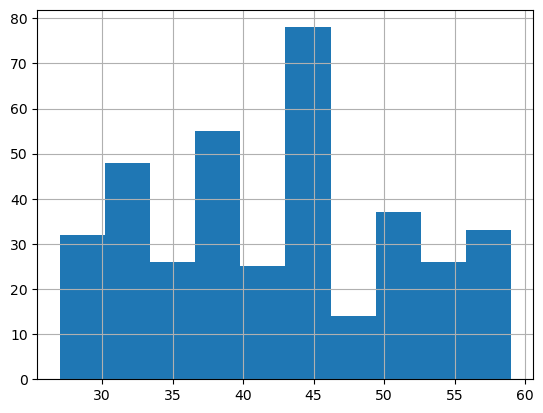

In [14]:
import matplotlib.pyplot as plt
data['Age'].hist()
plt.show()

In [15]:
data['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [16]:
data.corr(numeric_only=True)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Person ID,1.000000,0.990516,0.296305,0.431612,0.149882,-0.394287,-0.225467,0.043844
Age,0.990516,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.296305,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.431612,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.149882,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.394287,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225467,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.043844,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


<Axes: xlabel='Gender', ylabel='Stress Level'>

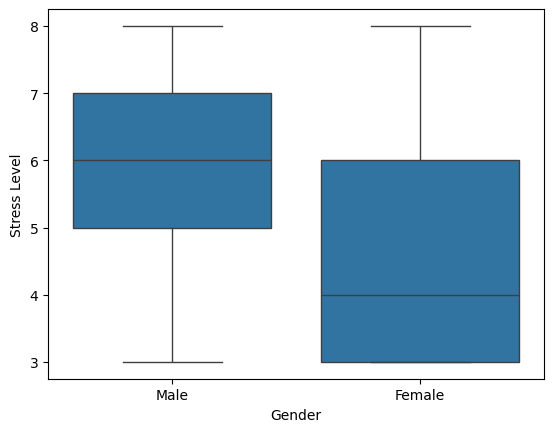

In [17]:
sns.boxplot(x='Gender',y='Stress Level', data=data)

In [18]:
data.corr(numeric_only=True)['Stress Level'].sort_values(ascending=False)

Stress Level               1.000000
Heart Rate                 0.670026
Daily Steps                0.186829
Physical Activity Level   -0.034134
Person ID                 -0.394287
Age                       -0.422344
Sleep Duration            -0.811023
Quality of Sleep          -0.898752
Name: Stress Level, dtype: float64

<Axes: >

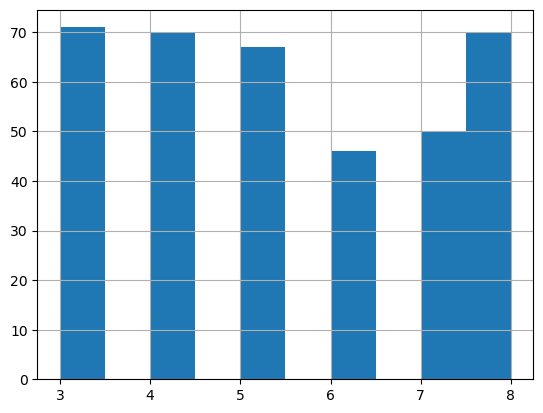

In [19]:
data['Stress Level'].hist()

<Axes: >

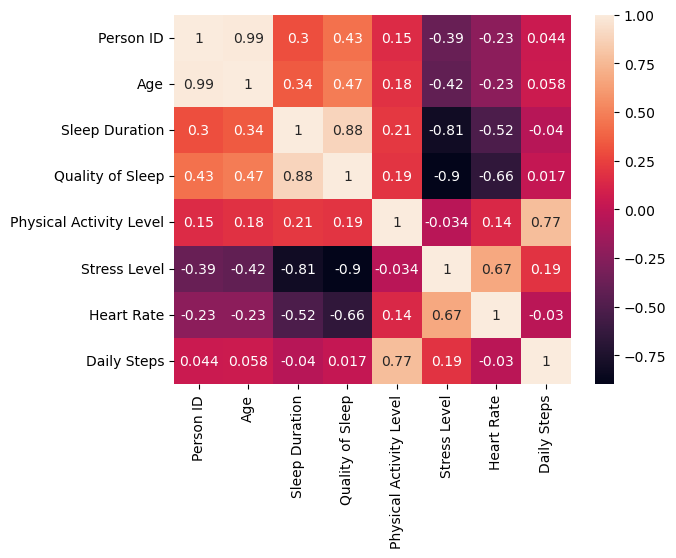

In [20]:
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)

<Axes: xlabel='Sleep Duration', ylabel='Stress Level'>

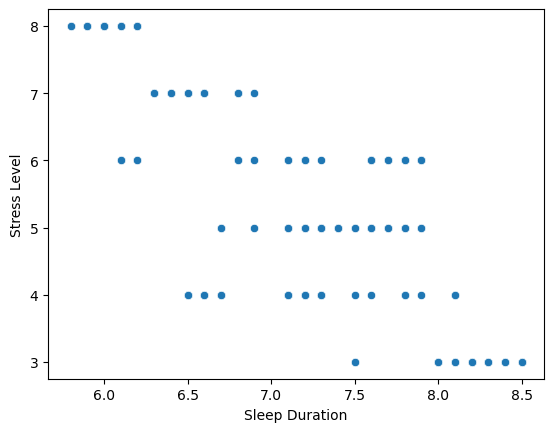

In [21]:
sns.scatterplot(x='Sleep Duration', y='Stress Level', data=data)

In [22]:
data.drop("Person ID", axis=1, inplace=True)

In [23]:
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Nothing
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Nothing
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Nothing
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [24]:
cat_cols = data.select_dtypes(include=['object','category']).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']


In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [26]:
label_encoder=LabelEncoder()

In [27]:
cat_cols=['Gender','Occupation','BMI Category','Sleep Disorder']
for col in cat_cols:
    data[col] = label_encoder.fit_transform(data[col])

data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,27,9,6.1,6,42,6,2,126/83,77,4200,1
1,1,28,1,6.2,6,60,8,0,125/80,75,10000,1
2,1,28,1,6.2,6,60,8,0,125/80,75,10000,1
3,1,28,6,5.9,4,30,8,1,140/90,85,3000,2
4,1,28,6,5.9,4,30,8,1,140/90,85,3000,2


In [28]:
data.tail(2)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
372,0,59,5,8.1,9,75,3,2,140/95,68,7000,2
373,0,59,5,8.1,9,75,3,2,140/95,68,7000,2


In [29]:
# Split Blood Pressure column into two columns
data[['Systolic BP', 'Diastolic BP']] = data['Blood Pressure'].str.split('/', expand=True)

# Convert them to numeric
data[['Systolic BP', 'Diastolic BP']] = data[['Systolic BP', 'Diastolic BP']].apply(pd.to_numeric)

# Drop original column
data = data.drop('Blood Pressure', axis=1)

In [30]:
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90


In [31]:
stress_level_index = data.columns.get_loc('Stress Level')

columns = list(data.columns[:stress_level_index]) + list(data.columns[stress_level_index+1:]) + ['Stress Level']

data = data[columns]
data.tail()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,Stress Level
369,0,59,5,8.1,9,75,2,68,7000,2,140,95,3
370,0,59,5,8.0,9,75,2,68,7000,2,140,95,3
371,0,59,5,8.1,9,75,2,68,7000,2,140,95,3
372,0,59,5,8.1,9,75,2,68,7000,2,140,95,3
373,0,59,5,8.1,9,75,2,68,7000,2,140,95,3


In [32]:
data['Occupation'].unique()

array([ 9,  1,  6, 10,  5,  2,  0,  8,  3,  7,  4])

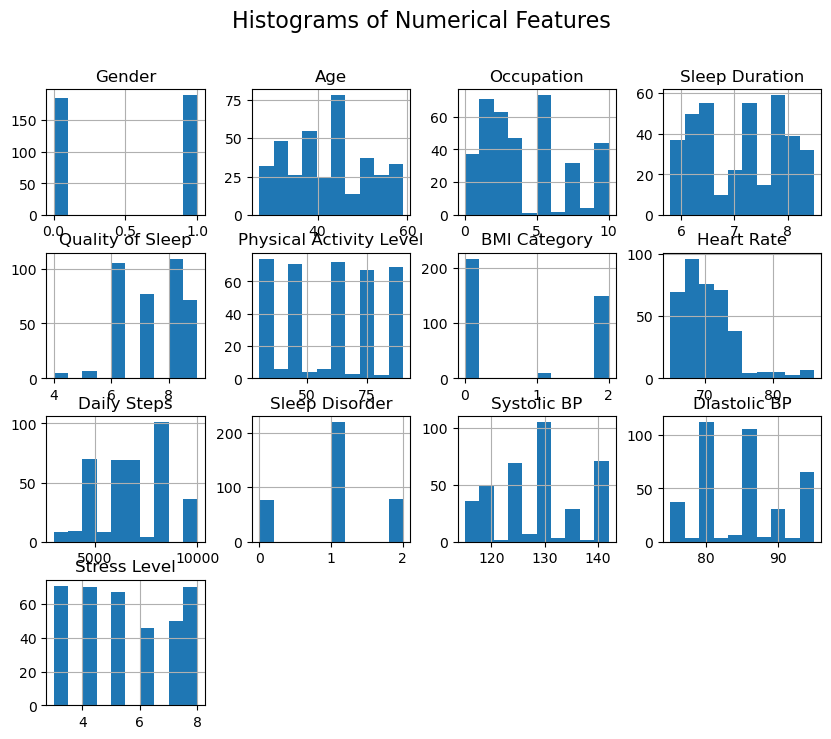

In [33]:
data.hist(figsize=(10, 8))
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

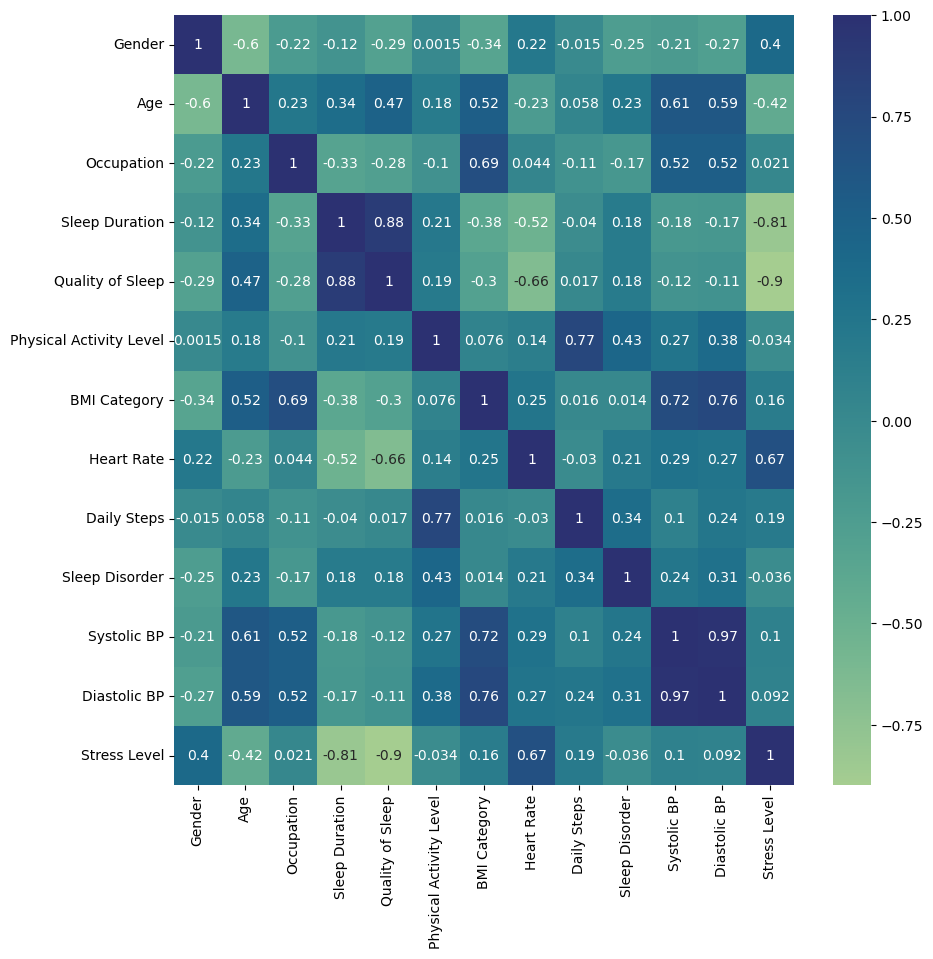

In [34]:
plt.figure(figsize = (10, 10))
sns.heatmap(data.corr(), cmap = 'crest', annot = True)
plt.show

In [35]:
data.drop(columns=["Physical Activity Level"], inplace=True)

In [36]:
X = data.drop("Stress Level", axis=1)
y = data["Stress Level"]

In [37]:
from sklearn.model_selection import train_test_split     
from sklearn.metrics import confusion_matrix           
from sklearn.metrics import classification_report       

from sklearn.linear_model import LogisticRegression    
from sklearn.ensemble import RandomForestClassifier    
from sklearn.tree import DecisionTreeClassifier        
from sklearn import svm                         
from sklearn.naive_bayes import GaussianNB            
from sklearn.neighbors import KNeighborsClassifier 

In [38]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (299, 11)
y_train shape: (299,)
X_test shape: (75, 11)
y_test shape: (75,)


In [39]:
X_train

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
192,1,43,7,6.5,6,2,72,6000,0,130,85
75,1,33,1,6.0,6,0,72,5000,1,125,80
84,1,35,9,7.5,8,0,70,8000,1,120,80
362,0,59,5,8.2,9,2,68,7000,2,140,95
16,0,29,5,6.5,5,0,80,4000,2,132,87
...,...,...,...,...,...,...,...,...,...,...,...
71,1,33,1,6.1,6,0,72,5000,1,125,80
106,0,37,5,6.1,6,2,77,4200,1,126,83
270,0,49,5,6.1,6,2,75,10000,2,140,95
348,0,57,5,8.2,9,2,68,7000,2,140,95


In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [41]:
predictions = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.056133333333333306
R2 Score: 0.9894972686923865


In [43]:
from sklearn.metrics import confusion_matrix

# Round predictions
rounded_preds = predictions.round().astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, rounded_preds)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[12  0  0  0  0  0]
 [ 0 10  0  0  0  0]
 [ 0  0 11  3  0  0]
 [ 0  0  1  9  0  0]
 [ 0  0  0  0 12  0]
 [ 0  0  0  0  1 16]]


In [44]:
rounded_preds = predictions.round().astype(int)
from sklearn.metrics import classification_report

print(classification_report(y_test, rounded_preds))

              precision    recall  f1-score   support

           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        10
           5       0.92      0.79      0.85        14
           6       0.75      0.90      0.82        10
           7       0.92      1.00      0.96        12
           8       1.00      0.94      0.97        17

    accuracy                           0.93        75
   macro avg       0.93      0.94      0.93        75
weighted avg       0.94      0.93      0.93        75



In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, r2])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model","MAE","R2 Score"])
print(results_df)

               Model       MAE  R2 Score
0  Linear Regression  0.251521  0.953039
1      Decision Tree  0.026667  0.991465
2      Random Forest  0.056133  0.989497


In [45]:
import numpy as np

def get_user_input():
    gender = int(input("Gender (Male=1, Female=0): "))
    age = int(input("Age: "))
    
    print("\nOccupation Encoding:")
    print("Scientist=0, Doctor=1, Accountant=2, Teacher=3, Manager=4, Engineer=5,")
    print("Sales Rep=6, Salesperson=7, Lawyer=8, Software Engineer=9, Nurse=10")
    occupation = int(input("Enter occupation code: "))

    sleep_duration = float(input("Sleep Duration (hours): "))
    
    print("\nBMI Category Encoding:")
    print("Normal=0, Overweight=1, Obese=2")
    bmi_category = int(input("Enter BMI category: "))

    heart_rate = int(input("Heart Rate (bpm): "))
    daily_steps = int(input("Daily Steps: "))
    systolic_bp = int(input("Systolic BP: "))
    diastolic_bp = int(input("Diastolic BP: "))
    sleep_disorder = int(input("Sleep Disorder (0=None,1=Insomnia,2=Sleep Apnea): "))

    return np.array([[gender, age, occupation, sleep_duration,
                      bmi_category, heart_rate, daily_steps,
                      sleep_disorder, systolic_bp, diastolic_bp]])